In [6]:
# Data Handling
import pandas as pd
import numpy as np

# Regular Expressions
import re

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.ensemble import RandomForestClassifier

from sklearn.neural_network import MLPClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# Save Model
import joblib

# Sparse Matrix
from scipy.sparse import hstack

In [7]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to C:\Users\adv
[nltk_data]     danish\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\adv
[nltk_data]     danish\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\adv
[nltk_data]     danish\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [8]:
df = pd.read_csv("phishing_email.csv")

df.head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [9]:
print("Shape of Dataset :", df.shape)

Shape of Dataset : (82486, 2)


In [10]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82486 entries, 0 to 82485
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text_combined  82486 non-null  object
 1   label          82486 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


,text_combined,label
count,82486,82486.000000
unique,82078,NaN
top,charity sees need cost dear friend read want f...,NaN
freq,3,NaN
mean,NaN,0.519979
std,NaN,0.499604
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,1.000000
75%,NaN,1.000000


In [11]:
df.isnull().sum()

text_combined    0
label            0
dtype: int64

In [12]:
print("Duplicate Emails :", df.duplicated().sum())

Duplicate Emails : 408


In [13]:
df.drop_duplicates(inplace=True)

print(df.shape)

(82078, 2)


In [14]:
df["label"].value_counts()

label
1    42845
0    39233
Name: count, dtype: int64

In [15]:
(df["label"].value_counts(normalize=True)*100).round(2)

label
1    52.2
0    47.8
Name: proportion, dtype: float64

In [16]:
label_names = {
    0: "Legitimate",
    1: "Phishing"
}

df["Email Type"] = df["label"].map(label_names)

C:\Users\adv danish\AppData\Local\Temp\ipykernel_27372\1716046289.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


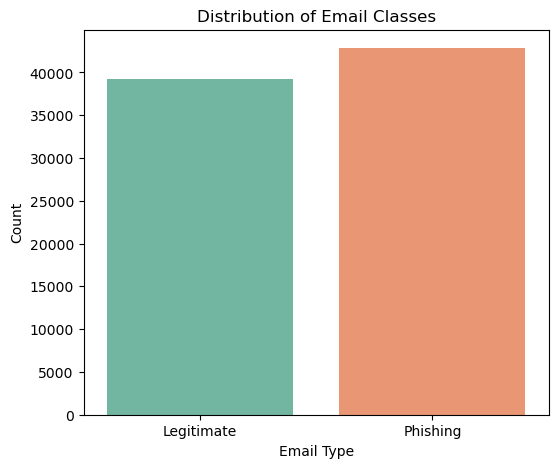

In [17]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Email Type",
    palette="Set2"
)

plt.title("Distribution of Email Classes")

plt.xlabel("Email Type")

plt.ylabel("Count")

plt.show()

## Observations

- Dataset contains over **82,000 emails**.
- The dataset has **no missing values**.
- Duplicate records were checked and removed if present.
- The classes are fairly balanced, making the dataset suitable for supervised machine learning.

# Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand the characteristics of phishing and legitimate emails. We analyze class distribution, email length, word count, metadata features, and frequently occurring words before building machine learning models.

In [18]:
print(df.head())
print(df.tail())
print(df.sample(5,random_state=42))

                                       text_combined  label  Email Type
0  hpl nom may 25 2001 see attached file hplno 52...      0  Legitimate
1  nom actual vols 24 th forwarded sabrae zajac h...      0  Legitimate
2  enron actuals march 30 april 1 201 estimated a...      0  Legitimate
3  hpl nom may 30 2001 see attached file hplno 53...      0  Legitimate
4  hpl nom june 1 2001 see attached file hplno 60...      0  Legitimate
                                           text_combined  label Email Type
82481  info advantageapartmentscom infoadvantageapart...      1   Phishing
82482  monkeyorg helpdeskmonkeyorg monkeyorg hi josep...      1   Phishing
82483  help center infohelpcentercoza_infohelpcenterc...      1   Phishing
82484  metamask infosofamekarcom verify metamask wall...      1   Phishing
82485  fastway infofastwaycoza_infofastwaycoza_infofa...      1   Phishing
                                           text_combined  label  Email Type
7288   garp 2001 convention invitation spe

In [19]:
print("Shape of Dataset :", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape of Dataset : (82078, 3)

Columns:
Index(['text_combined', 'label', 'Email Type'], dtype='object')

Data Types:
text_combined    object
label             int64
Email Type       object
dtype: object


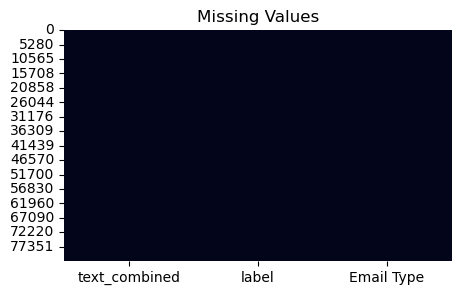

In [20]:
plt.figure(figsize=(5,3))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values")

plt.show()

C:\Users\adv danish\AppData\Local\Temp\ipykernel_27372\156653523.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


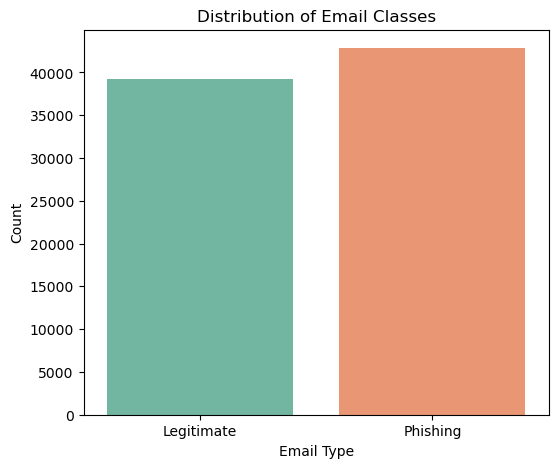

In [21]:
plt.figure(figsize=(6,5))

sns.countplot(
    x=df["Email Type"],
    palette="Set2"
)

plt.title("Distribution of Email Classes")

plt.xlabel("Email Type")

plt.ylabel("Count")

plt.show()

In [22]:
df["email_length"] = df["text_combined"].str.len()

In [23]:
df["email_length"].describe()

count    8.207800e+04
mean     1.290496e+03
std      1.553506e+04
min      1.000000e+00
25%      2.760000e+02
50%      5.580000e+02
75%      1.339000e+03
max      4.279526e+06
Name: email_length, dtype: float64

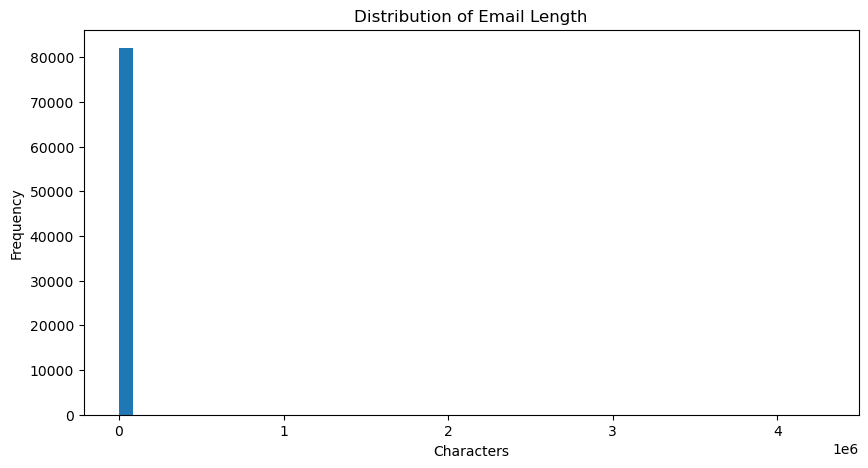

In [24]:
plt.figure(figsize=(10,5))

plt.hist(df["email_length"], bins=50)

plt.title("Distribution of Email Length")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

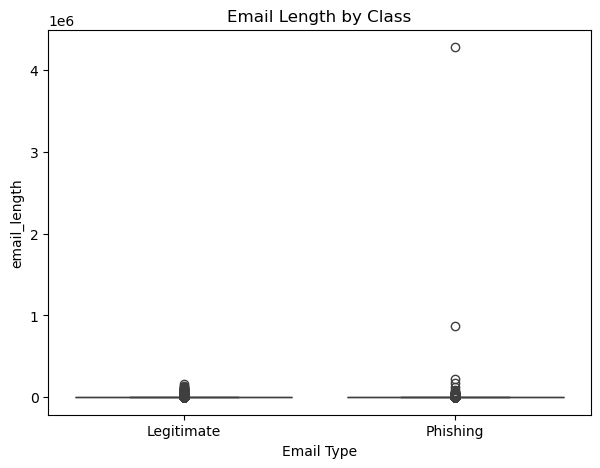

In [25]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x=df["Email Type"],
    y=df["email_length"]
)

plt.title("Email Length by Class")

plt.show()

In [26]:
df["word_count"] = df["text_combined"].apply(lambda x: len(x.split()))

In [27]:
df["word_count"].describe()

count     82078.000000
mean        160.715003
std         544.992481
min           0.000000
25%          39.000000
50%          78.000000
75%         183.000000
max      107710.000000
Name: word_count, dtype: float64

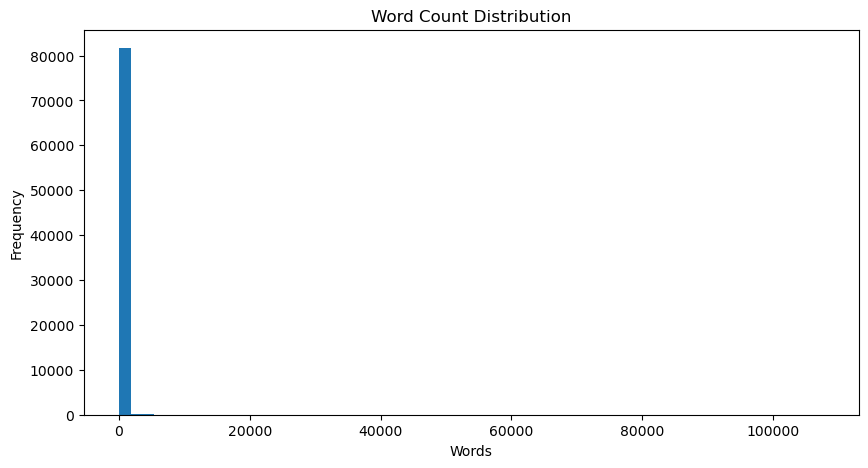

In [28]:
plt.figure(figsize=(10,5))

plt.hist(df["word_count"], bins=60)

plt.title("Word Count Distribution")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()

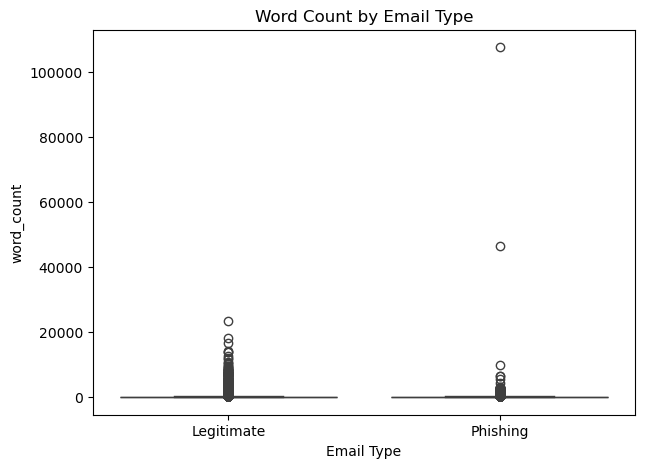

In [29]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x=df["Email Type"],
    y=df["word_count"]
)

plt.title("Word Count by Email Type")

plt.show()

In [30]:
def avg_word_length(text):
    words = text.split()

    if len(words)==0:
        return 0

    return sum(len(word) for word in words)/len(words)

df["avg_word_length"] = df["text_combined"].apply(avg_word_length)

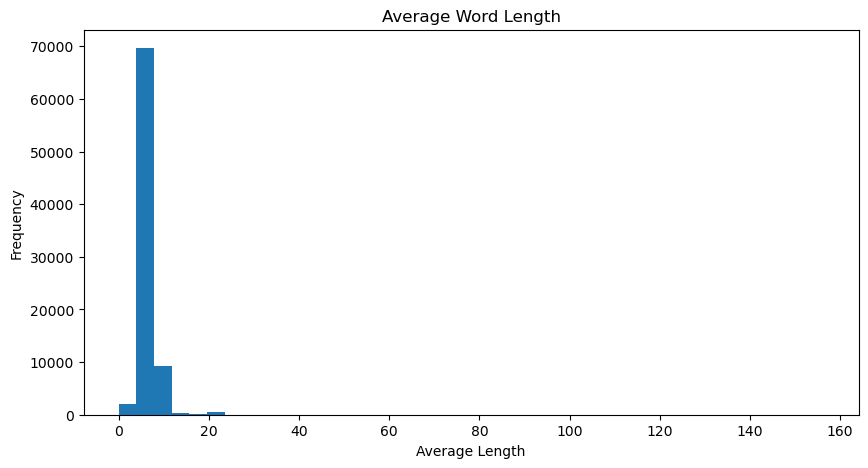

In [31]:
plt.figure(figsize=(10,5))

plt.hist(df["avg_word_length"], bins=40)

plt.title("Average Word Length")

plt.xlabel("Average Length")

plt.ylabel("Frequency")

plt.show()

In [32]:
import re

def count_urls(text):

    pattern=r"(https?://\S+|www\.\S+)"

    return len(re.findall(pattern,text))

df["url_count"]=df["text_combined"].apply(count_urls)

df["url_count"].describe()

count    82078.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: url_count, dtype: float64

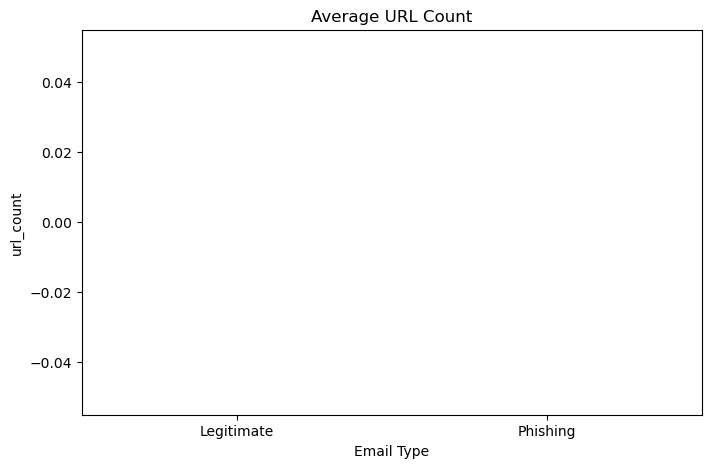

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=df["Email Type"],
    y=df["url_count"],
    estimator=np.mean
)

plt.title("Average URL Count")

plt.show()

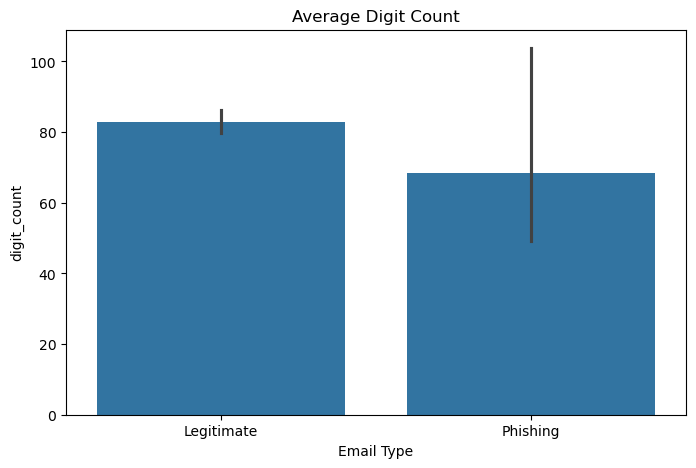

In [34]:
def digit_count(text):
    return sum(ch.isdigit() for ch in text)

df["digit_count"]=df["text_combined"].apply(digit_count)

plt.figure(figsize=(8,5))

sns.barplot(
    x=df["Email Type"],
    y=df["digit_count"],
    estimator=np.mean
)

plt.title("Average Digit Count")

plt.show()

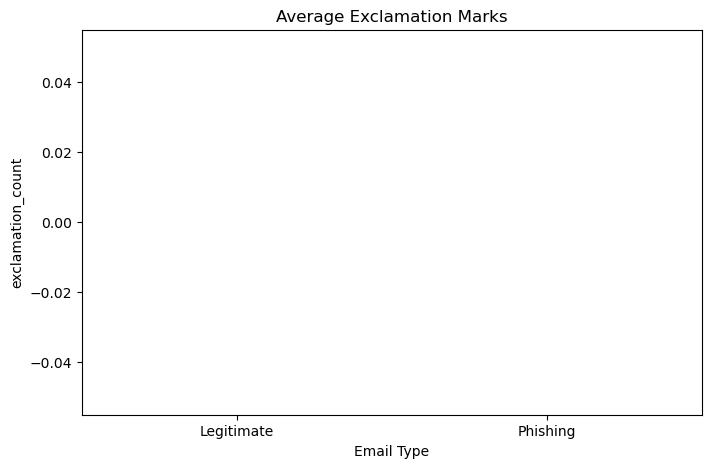

In [35]:
df["exclamation_count"] = df["text_combined"].str.count("!")


plt.figure(figsize=(8,5))

sns.barplot(
    x=df["Email Type"],
    y=df["exclamation_count"],
    estimator=np.mean
)

plt.title("Average Exclamation Marks")

plt.show()


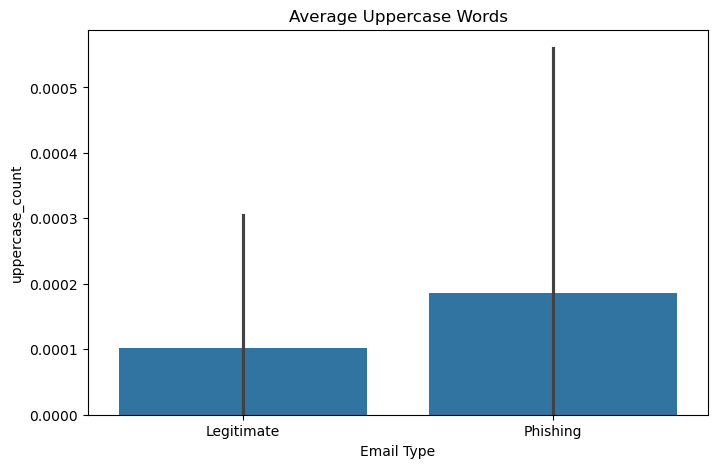

In [36]:
def uppercase_count(text):
    return sum(word.isupper() for word in text.split())

df["uppercase_count"] = df["text_combined"].apply(uppercase_count)

plt.figure(figsize=(8,5))

sns.barplot(
    x=df["Email Type"],
    y=df["uppercase_count"],
    estimator=np.mean
)

plt.title("Average Uppercase Words")

plt.show()

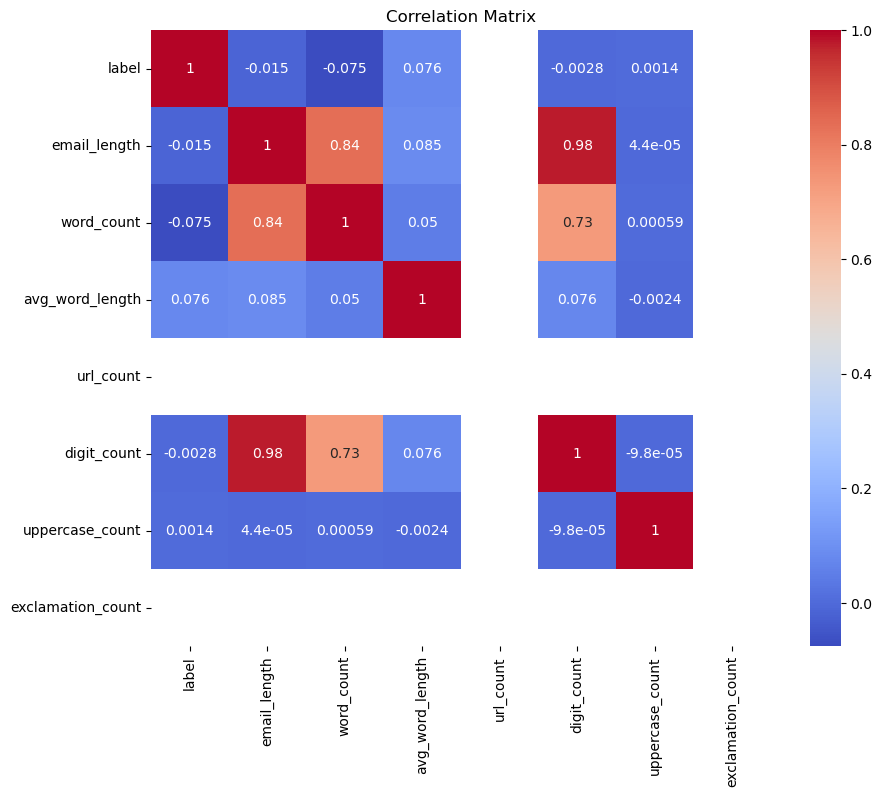

In [37]:
numeric_df = df[
    [
        "label",
        "email_length",
        "word_count",
        "avg_word_length",
        "url_count",
        "digit_count",
        "uppercase_count",
        "exclamation_count"
    ]
]


plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [38]:
df.groupby("Email Type")[
    [
        "email_length",
        "word_count",
        "url_count",
        "digit_count",
        "uppercase_count"
    ]
].mean()



,email_length,word_count,url_count,digit_count,uppercase_count
Email Type,,,,,
Legitimate,1541.456147,203.703897,0.0,82.858028,0.000102
Phishing,1060.692520,121.350239,0.0,68.389917,0.000187


## Text Preprocessing

In [39]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()



In [40]:
def clean_email(text):

    # Convert to lowercase
    text = text.lower()

    # Replace URLs
    text = re.sub(r"(https?://\S+|www\.\S+)", " URL ", text)

    # Replace email addresses
    text = re.sub(r"[\w\.-]+@[\w\.-]+", " EMAIL ", text)

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove punctuation
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenization
    words = text.split()

    # Remove stopwords & Lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df["clean_text"] = df["text_combined"].apply(clean_email)

In [41]:
comparison = df[["text_combined", "clean_text"]]

comparison.head(10)

,text_combined,clean_text
0,hpl nom may 25 2001 see attached file hplno 52...,hpl nom may see attached file hplno xl hplno xl
1,nom actual vols 24 th forwarded sabrae zajac h...,nom actual vols th forwarded sabrae zajac hou ...
2,enron actuals march 30 april 1 201 estimated a...,enron actuals march april estimated actuals ma...
3,hpl nom may 30 2001 see attached file hplno 53...,hpl nom may see attached file hplno xl hplno xl
4,hpl nom june 1 2001 see attached file hplno 60...,hpl nom june see attached file hplno xl hplno xl
5,hpl nom may 31 2001 see attached file hplno 53...,hpl nom may see attached file hplno xl hplno xl
6,9760 tried get fancy address came back forward...,tried get fancy address came back forwarded la...
7,hpl noms february 15 2000 see attached file hp...,hpl noms february see attached file hplo xl hp...
8,fw pooling contract template original message ...,fw pooling contract template original message ...
9,hpl nom march 28 2000 see attached file hplo 3...,hpl nom march see attached file hplo xl hplo xl


In [42]:
(df["clean_text"].str.len() == 0).sum()


np.int64(2)

In [43]:
df = df[df["clean_text"].str.strip() != ""]

In [44]:
print(df.shape)

(82076, 11)


In [45]:
df.to_csv("cleaned_phishing_email.csv", index=False)

# Feature Engineering

In [46]:
# Total number of characters
df["email_length"] = df["text_combined"].str.len()

In [47]:
# Total number of words
df["word_count"] = df["text_combined"].apply(lambda x: len(str(x).split()))

In [48]:
def average_word_length(text):

    words = text.split()

    if len(words) == 0:
        return 0

    return sum(len(word) for word in words) / len(words)

df["avg_word_length"] = df["text_combined"].apply(average_word_length)

In [49]:
def count_urls(text):

    urls = re.findall(r"(https?://\S+|www\.\S+)", text)

    return len(urls)

df["url_count"] = df["text_combined"].apply(count_urls)

In [50]:
def count_email(text):

    emails = re.findall(r"[\w\.-]+@[\w\.-]+", text)

    return len(emails)

df["email_count"] = df["text_combined"].apply(count_email)

In [51]:
def digit_count(text):

    return sum(ch.isdigit() for ch in text)

df["digit_count"] = df["text_combined"].apply(digit_count)

In [52]:
df["exclamation_count"] = df["text_combined"].str.count("!")

df["question_count"] = df["text_combined"].str.count(r"\?")

In [53]:
def uppercase_words(text):

    return sum(word.isupper() for word in text.split())

df["uppercase_count"] = df["text_combined"].apply(uppercase_words)

In [54]:
def special_character_count(text):

    return len(re.findall(r"[@#$%^&*()_+=<>?/{}~|]", text))

df["special_char_count"] = df["text_combined"].apply(special_character_count)

In [55]:
def currency_count(text):

    return len(re.findall(r"[$₹€£]", text))

df["currency_count"] = df["text_combined"].apply(currency_count)

In [56]:
suspicious_words = [

    "verify",

    "login",

    "account",

    "bank",

    "password",

    "click",

    "urgent",

    "winner",

    "prize",

    "gift",

    "security",

    "limited",

    "confirm",

    "payment",

    "invoice",

    "refund",

    "update",

    "bitcoin",

    "otp",

    "reset"

]

In [57]:
def suspicious_word_count(text):

    text = text.lower()

    return sum(text.count(word) for word in suspicious_words)

df["suspicious_count"] = df["text_combined"].apply(suspicious_word_count)

In [58]:
urgency_words = [

    "urgent",

    "immediately",

    "now",

    "today",

    "hurry",

    "important",

    "asap",

    "alert"

]

In [59]:
def urgency_score(text):

    text = text.lower()

    return sum(text.count(word) for word in urgency_words)

df["urgency_score"] = df["text_combined"].apply(urgency_score)

In [60]:
feature_columns = [

    "email_length",

    "word_count",

    "avg_word_length",

    "url_count",

    "email_count",

    "digit_count",

    "exclamation_count",

    "question_count",

    "uppercase_count",

    "special_char_count",

    "currency_count",

    "suspicious_count",

    "urgency_score"

]

df[feature_columns].head()

,email_length,word_count,avg_word_length,url_count,email_count,digit_count,exclamation_count,question_count,uppercase_count,special_char_count,currency_count,suspicious_count,urgency_score
0,65,14,3.714286,0,0,12,0,0,0,0,0,0,0
1,1071,208,4.153846,0,0,135,0,0,0,0,0,0,1
2,148,28,4.321429,0,0,28,0,0,0,0,0,0,0
3,65,14,3.714286,0,0,12,0,0,0,0,0,0,0
4,65,14,3.714286,0,0,11,0,0,0,0,0,0,0


In [61]:
df[feature_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
email_length,82076.0,1290.527267,15535.252252,3.000000,276.000000,558.000000,1339.000000,4.279526e+06
word_count,82076.0,160.718895,544.998551,1.000000,39.000000,78.000000,183.000000,1.077100e+05
avg_word_length,82076.0,6.600475,2.547773,1.003731,5.571429,6.261511,7.037396,1.563333e+02
url_count,82076.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
email_count,82076.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
digit_count,82076.0,75.307435,2604.286302,0.000000,16.000000,27.000000,52.000000,7.407260e+05
exclamation_count,82076.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
question_count,82076.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
uppercase_count,82076.0,0.000146,0.030027,0.000000,0.000000,0.000000,0.000000,8.000000e+00
special_char_count,82076.0,8.692188,48.965785,0.000000,0.000000,0.000000,0.000000,5.151000e+03


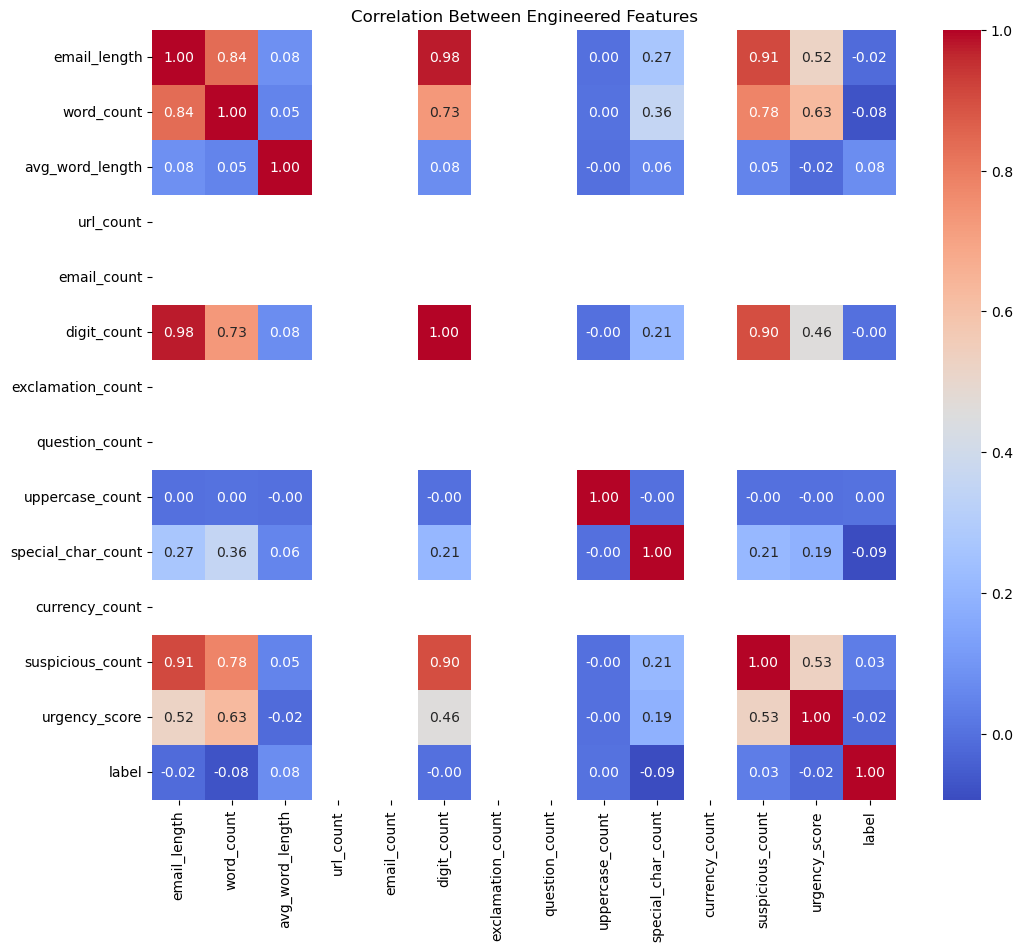

In [62]:
plt.figure(figsize=(12,10))

sns.heatmap(

    df[feature_columns + ["label"]].corr(),

    annot=True,

    cmap="coolwarm",

    fmt=".2f"

)

plt.title("Correlation Between Engineered Features")

plt.show()

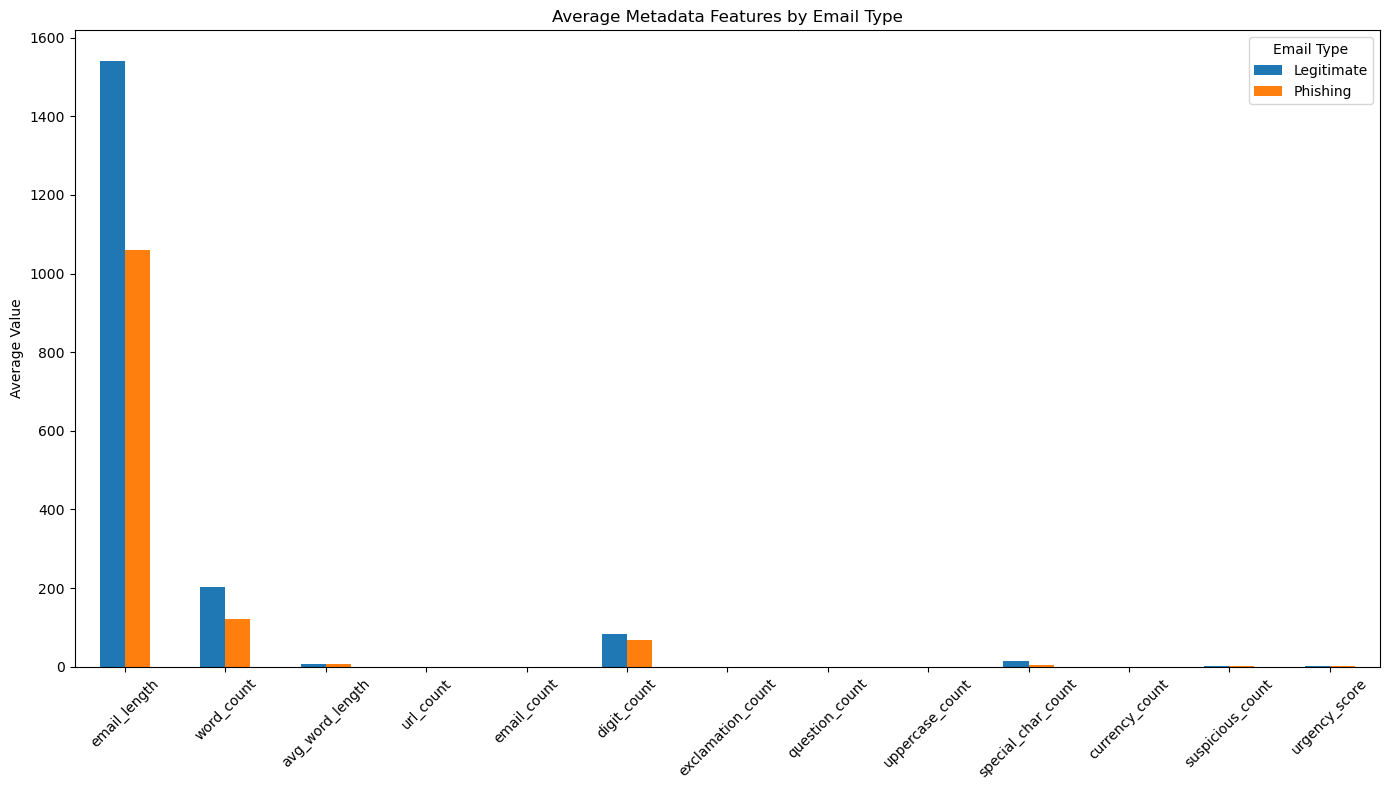

In [63]:
feature_means = df.groupby("Email Type")[feature_columns].mean()

feature_means.T.plot(

    kind="bar",

    figsize=(14,8)

)

plt.title("Average Metadata Features by Email Type")

plt.ylabel("Average Value")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Feature Engineering Summary

The following metadata features were extracted:

- Email Length
- Word Count
- Average Word Length
- URL Count
- Email Address Count
- Digit Count
- Exclamation Count
- Question Mark Count
- Uppercase Word Count
- Special Character Count
- Currency Symbol Count
- Suspicious Keyword Count
- Urgency Score

These features capture structural characteristics commonly observed in phishing emails and will be combined with TF-IDF text features to build a more robust phishing detection model.

# Feature Extraction

In [64]:

X_text = df["clean_text"]


y = df["label"]

In [65]:


tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

In [66]:
X_tfidf = tfidf.fit_transform(X_text)

print("TF-IDF Shape :", X_tfidf.shape)

TF-IDF Shape : (82076, 5000)


In [67]:
metadata_features = [

    "email_length",

    "word_count",

    "avg_word_length",

    "url_count",

    "email_count",

    "digit_count",

    "exclamation_count",

    "question_count",

    "uppercase_count",

    "special_char_count",

    "currency_count",

    "suspicious_count",

    "urgency_score"

]

metadata = df[metadata_features].values

print(metadata.shape)

(82076, 13)


In [68]:
X = hstack([X_tfidf, metadata])

print("Final Feature Matrix Shape:", X.shape)

Final Feature Matrix Shape: (82076, 5013)


In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [70]:
print(X_train.shape)

(65660, 5013)


# Model Training and Evaluation

In [71]:
import time

from sklearn.metrics import roc_auc_score

results = []

def evaluate_model(model, model_name):

    start = time.time()

    model.fit(X_train, y_train)

    end = time.time()

    train_time = end - start

    predictions = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_test)[:,1]
    else:
        probabilities = predictions

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(y_test, predictions)

    recall = recall_score(y_test, predictions)

    f1 = f1_score(y_test, predictions)

    roc_auc = roc_auc_score(y_test, probabilities)

    results.append({

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC-AUC": roc_auc,

        "Training Time (s)": train_time

    })

    print("="*60)

    print(model_name)

    print("="*60)

    print(classification_report(y_test,predictions))

    cm = confusion_matrix(y_test,predictions)

    ConfusionMatrixDisplay(cm).plot(cmap="Blues")

    plt.title(model_name)

    plt.show()

Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      7847
           1       0.95      0.96      0.95      8569

    accuracy                           0.95     16416
   macro avg       0.95      0.95      0.95     16416
weighted avg       0.95      0.95      0.95     16416



C:\Users\adv danish\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


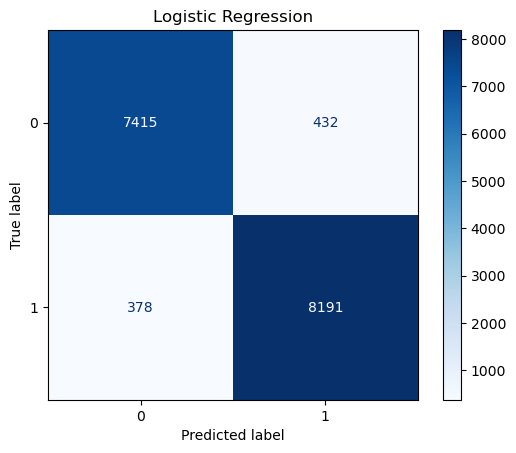

In [72]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

evaluate_model(
    lr,
    "Logistic Regression"
)

Random Forest
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7847
           1       0.98      0.98      0.98      8569

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416



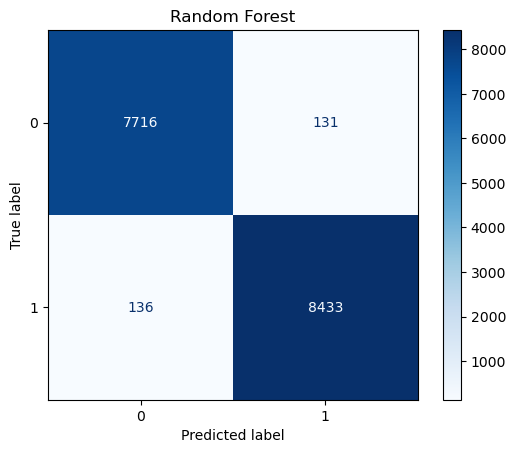

In [90]:
rf = RandomForestClassifier(

    n_estimators=100,

    random_state=42,

    n_jobs=-1
)

evaluate_model(
    rf,
    "Random Forest"
)

Naive Bayes
              precision    recall  f1-score   support

           0       0.78      0.83      0.80      7847
           1       0.83      0.79      0.81      8569

    accuracy                           0.81     16416
   macro avg       0.81      0.81      0.81     16416
weighted avg       0.81      0.81      0.81     16416



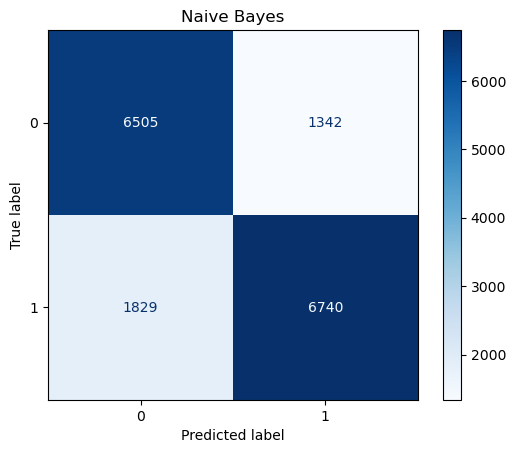

In [91]:
nb = MultinomialNB()

evaluate_model(
    nb,
    "Naive Bayes"
)

In [92]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (s)
0,Logistic Regression,0.950658,0.949901,0.955888,0.952885,0.987329,23.106867
1,Naive Bayes,0.806835,0.833952,0.786556,0.809561,0.845022,0.033947
2,Random Forest,0.983735,0.984703,0.984129,0.984416,0.998586,48.372531
3,Random Forest,0.983735,0.984703,0.984129,0.984416,0.998586,75.134778
4,Random Forest,0.983735,0.984703,0.984129,0.984416,0.998586,92.452560
5,Naive Bayes,0.806835,0.833952,0.786556,0.809561,0.845022,0.099884


In [93]:
results_df = results_df.sort_values(

    by="Accuracy",

    ascending=False

)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (s)
2,Random Forest,0.983735,0.984703,0.984129,0.984416,0.998586,48.372531
3,Random Forest,0.983735,0.984703,0.984129,0.984416,0.998586,75.134778
4,Random Forest,0.983735,0.984703,0.984129,0.984416,0.998586,92.452560
0,Logistic Regression,0.950658,0.949901,0.955888,0.952885,0.987329,23.106867
1,Naive Bayes,0.806835,0.833952,0.786556,0.809561,0.845022,0.033947
5,Naive Bayes,0.806835,0.833952,0.786556,0.809561,0.845022,0.099884


In [94]:
results_df.to_csv(

    "model_comparison.csv",

    index=False

)

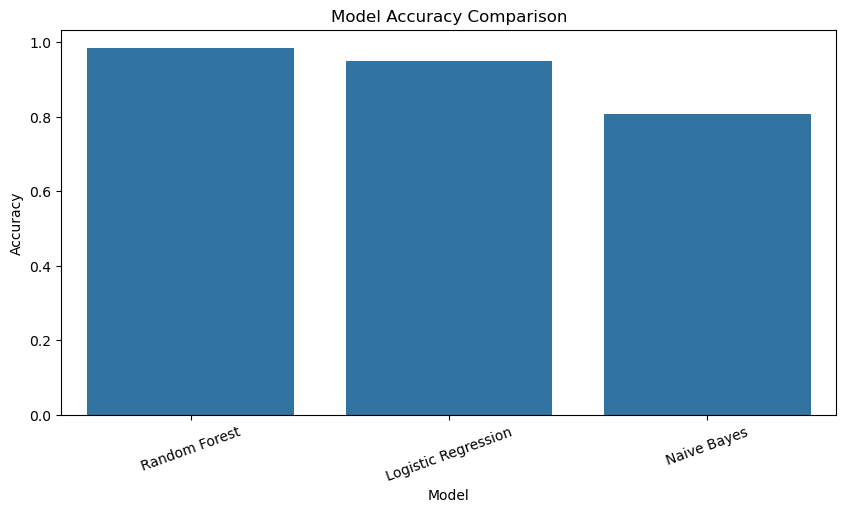

In [95]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=results_df,

    x="Model",

    y="Accuracy"

)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=20)

plt.show()

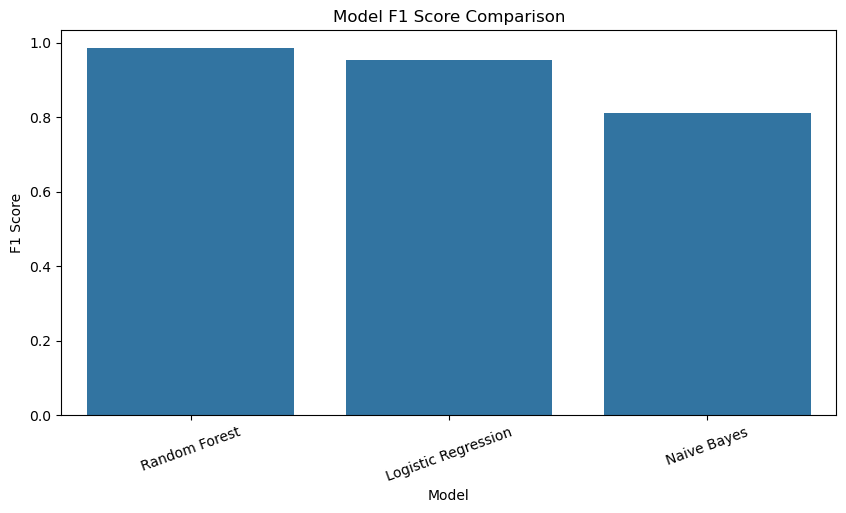

In [96]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=results_df,

    x="Model",

    y="F1 Score"

)

plt.title("Model F1 Score Comparison")

plt.xticks(rotation=20)

plt.show()

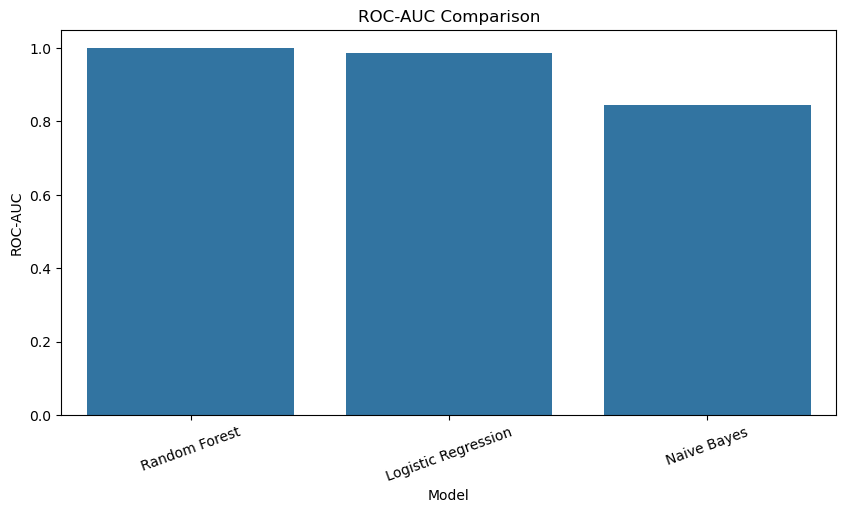

In [97]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=results_df,

    x="Model",

    y="ROC-AUC"

)

plt.title("ROC-AUC Comparison")

plt.xticks(rotation=20)

plt.show()

In [98]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : Random Forest


In [99]:
joblib.dump(rf, "model.pkl")
joblib.dump(tfidf, "vectorizer.pkl")

['vectorizer.pkl']

In [100]:
print("Model expects:", rf.n_features_in_)

Model expects: 5013


In [101]:
print("RF expects:", rf.n_features_in_)
print("X_train:", X_train.shape)

RF expects: 5013
X_train: (65660, 5013)


In [102]:
import joblib

joblib.dump(
    rf,
    "model.pkl",
    compress=3
)

joblib.dump(
    tfidf,
    "vectorizer.pkl",
    compress=3
)

['vectorizer.pkl']

In [103]:
print(rf.n_features_in_)

5013


In [104]:
print(len(tfidf.get_feature_names_out()))

5000


In [105]:
print(rf.n_features_in_)
print(len(tfidf.get_feature_names_out()))

5013
5000
